# Name-free labels for free-vocabulary NL→FOL translations: dataset demo

This notebook walks through the **`rcomp_free_labels`** group of the dataset artifact *"Name-free labels for free-vocabulary logic translations"* (T7b).

**What the dataset contains.** 221 templated English rule sentences (for example *"Each legislator who … is Emily's friend, except if …"*) were translated into first-order logic by 10 LLM slots from 9 model families. The prompts used **free vocabulary**: each model chose its own predicate and constant names. That gives **2,652 (sentence, candidate FOL) rows**. Each row gets a faithfulness label that **does not depend on symbol names**. An exhaustive search looks for a symbol map from the candidate's vocabulary onto the reference reading's vocabulary. The map is injective, and it may use the bridges B1/B2 (reification), B3 (merge), B4 (split) and B5 (lexical negation). The search uses z3 relevance/polarity prunes, 128-model finite countermodels and z3 equivalence checks. It hit 0 caps and returned 0 z3 `unknown` results.

| label | meaning | full-dataset count |
|---|---|---|
| `ERROR_CERT` | no admissible map makes the candidate equivalent to any reading of the sentence. This label is **final** and backed by a certificate | 759 |
| `UNRESOLVED_GLOSS_NOT_RUN` | some map makes it z3-equivalent (MAPPED), but the LLM **gloss check** (does each symbol really mean the mapped phrase?) has not run yet | 1,506 |
| `UNPARSEABLE` | the output does not parse as FOL | 188 |
| `NO_OUTPUT` | the model returned nothing | 199 |

The paid gloss step could not run: the run's OpenRouter budget was exhausted (deviation D9). So the labels are **search-only**, and no `CORRECT` class exists yet. The binary view `metadata_label_binary_search_provisional` (ERROR vs MAPPED) is provisional. An audit estimated about 13% contamination on each side.

**What the original script (`data.py`) does.** It assembles the three plan groups (`rcomp_free_labels`, `gloss_gate_items`, `sig_soundness_replay`) from the run's `results/*.jsonl`. It checks that each example has string `input`/`output` fields and no reserved keys. Then it attaches the seal and testability metadata and writes `full_data_out.json` in the `exp_sel_data_out` format. Here the same code runs on a **curated 100-row subset** of `rcomp_free_labels`: 40 ERROR_CERT, 40 UNRESOLVED, 10 UNPARSEABLE and 10 NO_OUTPUT, stratified by clause type and LLM family. The subset is loaded from GitHub. The notebook then explores and plots the labels.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — used by the original data.py, NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports
This is the original import block of `data.py`. The original also inserts `src/` and `vendor/` into `sys.path` so that it can import `build_output`. The notebook does not need those modules, because it reads the already-built rows from the demo JSON. It adds `pandas` and `matplotlib` for the analysis at the end.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions (analysis / plotting) ---
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
The loader fetches `mini_demo_data.json` from the GitHub repository. If that fails, it falls back to a local copy. The file has the same `exp_sel_data_out` layout as the artifact's `full_data_out.json`: a `metadata` block plus `datasets: [{dataset, examples}]`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-4/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({g["dataset"]: len(g["examples"]) for g in data["datasets"]})
print(data["metadata"]["demo_subset_note"])

{'rcomp_free_labels': 100}
100 of 2,652 rcomp_free_labels rows, stratified by label (40/40/10/10) x clause_type x LLM family (seed 0); corpus-level counts above refer to the full dataset.


## Config
`data.py` has no numeric hyperparameters. The only knobs are which groups to keep (`SELECTED`) and, in this notebook, how many rows of the demo subset to process.
- `MAX_EXAMPLES`: rows of `rcomp_free_labels` to run through the pipeline. The demo file holds 100, and the original run used all **2,652**.
- `N_SHOW`: how many decoded examples to print in the inspection cell.
- `SELECTED`: the original list of plan groups. Only `rcomp_free_labels` ships in the demo file. The other two groups (840 gloss-gate items and 4,280 SIG soundness-replay rows) are in the artifact's `full_data_out.json`.

In [5]:
MAX_EXAMPLES = 100   # demo subset size; original full run: 2652 rcomp_free_labels rows (+ 840 gate + 4280 SIG rows)
N_SHOW = 3           # decoded examples printed below

SELECTED = ["rcomp_free_labels", "gloss_gate_items", "sig_soundness_replay"]

## Logger setup (original)
This is the original loguru configuration: INFO to stdout, plus a DEBUG file sink under `logs/`. `ROOT` was the script's own folder. In the notebook it is the current working directory.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## How a row is built (from `src/build_output.py::free_group`)
In the original script, `B.free_group()` reads `results/free_labels_v2.jsonl` and turns each labelled record into one example:
- **`input`**: a JSON *string* with `text` (the English sentence), `candidate_fol` (the LLM's formula), `system`, `family`, `slot`, `prompt_variant`, `condition="FREE"` and `template_id`.
- **`output`**: the label (`ERROR_CERT`, `UNRESOLVED_GLOSS_NOT_RUN`, `UNPARSEABLE` or `NO_OUTPUT`).
- **`metadata_*`**: strata (`template_id`, `clause_type`, `words`, `word_tercile`, `nconds_weak`, `nested`, …) and the search evidence. The evidence includes `map_certificate` (the symbol map and the bridges it used), `n_maps_enumerated`, `n_equiv_maps`, `nonequiv_certificate_type_counts` (why the maps that were ruled out failed), `gloss_pairs` (the (symbol, meaning) pairs the gloss checker will judge), `seen_iter3`, and the old iter-3 label.

The notebook reuses that function's `md()` helper and the provisional binary mapping. In the cell below, `groups` comes from the loaded demo data rather than from `B.free_group(), B.gate_group(), B.sig_group()`.

In [7]:
def md(d: dict) -> dict:  # from build_output.py (used to prefix metadata keys)
    return {f"metadata_{k}": v for k, v in d.items()}

# original: import build_output as B; groups = [B.free_group(), B.gate_group(), B.sig_group()]
groups = [{"dataset": g["dataset"], "examples": g["examples"][:MAX_EXAMPLES]} for g in data["datasets"]]

# same provisional binary view that free_group() writes (ERROR vs MAPPED; everything else EXCLUDED)
for g in groups:
    for e in g["examples"]:
        search_bin = {"ERROR_CERT": "ERROR", "UNRESOLVED_GLOSS_NOT_RUN": "MAPPED"}.get(e["output"], "EXCLUDED")
        assert e["metadata_label_binary_search_provisional"] == search_bin, e["metadata_row_key"]
print({g["dataset"]: len(g["examples"]) for g in groups})

{'rcomp_free_labels': 100}


## `main()`: validate the groups and assemble the output file (original logic)
This follows the original `main()`. Every group must be non-empty, and every example must have string `input`/`output` and none of the reserved keys `split`/`dataset`/`context`. The script then builds the top-level metadata from the **seal** (sha256 hashes of the label vector for all rows and for the untouched subset, and of the preregistration) and from the **testability** report. That report applies the rule *TESTABLE iff ≥50 ERROR and ≥50 CORRECT rows, each class spread over ≥25 sentences*.

There is one change. The original read `seal` and `t` from `results/seal.json` and `results/testability_FREE_v2.json`. Here they are rebuilt from the metadata block that shipped with the data, so the same dictionary-building code runs unchanged. The output goes to `demo_data_out.json` instead of overwriting `full_data_out.json`.

In [8]:
M = data["metadata"]
# original: seal = json.loads((ROOT / "results" / "seal.json").read_text())["seals"][-1]
seal = {"mode": M["label_mode"], "label_vector_sha256_all_rows": M["seal_all_rows_sha256"],
        "label_vector_sha256_untouched": M["seal_untouched_sha256"], "prereg_sha256": M["prereg_sha256"]}
# original: t = json.loads((ROOT / "results" / "testability_FREE_v2.json").read_text())
t = {"all_rows": M["testability_all_rows"], "untouched_subset": M["testability_untouched"],
     "search_provisional_view": {k: {"TESTABLE": v} for k, v in M["provisional_view_testable"].items()}}


@logger.catch(reraise=True)
def main() -> None:
    for g in groups:
        assert g["examples"], g["dataset"]
        for e in g["examples"]:
            assert isinstance(e["input"], str) and isinstance(e["output"], str), g["dataset"]
            assert not ({"split", "dataset", "context"} & set(e)), g["dataset"]
    out = {"metadata": {
        "artifact": "T7b name-free labels for free-vocabulary rule translations (run_u75jRHUss0zo, iter 4, gen_art_dataset_5)",
        "workspace": str(ROOT),
        "selection": ("the three plan groups (chosen as best 3 of 6 standardised candidates; folio / malls_test / "
                      "logicnli_test were context only: no multi-system candidates, ~36-39% wrong gold, or no FOL; their "
                      "standardised record is temp/candidates_data_out.json)"),
        "label_mode": seal["mode"],
        "status_note": ("SEARCH-ONLY labels: the paid gloss step could not run (deviation D9: run OpenRouter budget "
                        "exhausted before this artifact's first call; re-probed at packaging, still HTTP 403). ERROR_CERT is "
                        "final and certificate-backed; MAPPED rows are UNRESOLVED_GLOSS_NOT_RUN until src/resume_gloss.py "
                        "runs. metadata_label_binary_search_provisional (ERROR vs MAPPED) is a provisional view with audited "
                        "contamination (results/soundness_audit.json)."),
        "seal_all_rows_sha256": seal["label_vector_sha256_all_rows"],
        "seal_untouched_sha256": seal.get("label_vector_sha256_untouched"),
        "prereg_sha256": seal["prereg_sha256"],
        "testability_all_rows": {k: t["all_rows"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "testability_untouched": {k: t["untouched_subset"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "provisional_view_testable": {k: t["search_provisional_view"][k]["TESTABLE"] for k in ("all_rows", "untouched_subset")},
    }, "datasets": [g for g in groups if g["dataset"] in SELECTED]}
    (ROOT / "demo_data_out.json").write_text(json.dumps(out, ensure_ascii=False))  # original: full_data_out.json
    logger.info(f"demo_data_out.json: {[(g['dataset'], len(g['examples'])) for g in out['datasets']]}")
    return out


out = main()
print(json.dumps({k: out["metadata"][k] for k in ("label_mode", "testability_all_rows", "provisional_view_testable")}, indent=1))

16:42:47|INFO   |demo_data_out.json: [('rcomp_free_labels', 100)]


{
 "label_mode": "search_only",
 "testability_all_rows": {
  "n_ERROR": 759,
  "n_CORRECT": 0,
  "TESTABLE": false,
  "label_counts": {
   "ERROR_CERT": 759,
   "UNRESOLVED_GLOSS_NOT_RUN": 1506,
   "UNPARSEABLE": 188,
   "NO_OUTPUT": 199
  }
 },
 "provisional_view_testable": {
  "all_rows": true,
  "untouched_subset": true
 }
}


## Inspect a few rows
Each `input` string is decoded to show the sentence, the free-vocabulary candidate and the label. For MAPPED rows the **map certificate** is printed as well: the candidate symbols mapped onto phrases of the reference reading, plus any bridges used. For ERROR_CERT rows the output shows how the non-equivalent maps were ruled out.

In [9]:
ex = out["datasets"][0]["examples"]
# one row per label, MAPPED (with a certificate) first, then ERROR_CERT, UNPARSEABLE, NO_OUTPUT
order = ["UNRESOLVED_GLOSS_NOT_RUN", "ERROR_CERT", "UNPARSEABLE", "NO_OUTPUT"]
picked = [next(e for e in ex if e["output"] == lab) for lab in order if any(e["output"] == lab for e in ex)][:N_SHOW]
for e in picked:
    inp = json.loads(e["input"])
    print("=" * 100)
    print(f"LABEL: {e['output']}   system: {inp['system']}   clause: {e['metadata_clause_type']}   words: {e['metadata_words']}")
    print("TEXT :", inp["text"])
    print("FOL  :", inp["candidate_fol"])
    if e["metadata_map_certificate"]:
        c = e["metadata_map_certificate"]
        print(f"MAP  : reading={c['reading']} bridges={c['bridges']}")
        for m in c["map"]:
            print("       ", m)
        print(f"       {e['metadata_n_equiv_maps']} equivalent maps in {e['metadata_n_equiv_map_orbits']} orbits "
              f"(of {e['metadata_n_maps_enumerated']} enumerated)")
    if e["metadata_nonequiv_certificate_type_counts"]:
        print("NON-EQUIV CERTS:", e["metadata_nonequiv_certificate_type_counts"])
    if e["metadata_unresolved_reason"]:
        print("UNRESOLVED:", e["metadata_unresolved_reason"])

LABEL: UNRESOLVED_GLOSS_NOT_RUN   system: G6:microsoft/phi-4   clause: as_long_as+unless   words: 31
TEXT : A flower that is peer-reviewed and that exceeds its elastic limit has a battery storage system so long as the flower is in an urban area, unless the flower is addictive.
FOL  : ∀x ((Flower(x) ∧ PeerReviewed(x) ∧ ExceedsElasticLimit(x) ∧ InUrbanArea(x) ∧ ¬Addictive(x)) → HasBatteryStorageSystem(x))
MAP  : reading=weak bridges=[]
        Addictive(x) => Addictive(x)
        ExceedsElasticLimit(x) => ExceedsElasticLimit(x)
        Flower(x) => Flower(x)
        HasBatteryStorageSystem(x) => HasBatteryStorageSystem(x)
        InUrbanArea(x) => InUrbanArea(x)
        PeerReviewed(x) => PeerReviewed(x)
       48 equivalent maps in 1 orbits (of 48 enumerated)
NON-EQUIV CERTS: {'count_prune_subtree': 291, 'no_polarity_compatible_target': 10}
UNRESOLVED: gloss check not run (D9: API budget exhausted)
LABEL: ERROR_CERT   system: G7:openai/gpt-4.1-mini   clause: as_long_as+unless   words: 3

## Results: label distribution, strata and search evidence
The rows are flattened into a table. The cells below report the following:
1. Label counts in the demo subset next to the full-dataset counts from the seal metadata.
2. The ERROR-vs-MAPPED provisional view per clause type and per word tercile (sentence-length bin), which shows how certificate-backed errors spread over sentence complexity.
3. The ERROR rate per LLM family.
4. The kinds of non-equivalence certificates, and the bridges used by successful maps.

In [10]:
df = pd.DataFrame([{**{k[len('metadata_'):]: v for k, v in e.items() if k.startswith('metadata_') and not isinstance(v, (dict, list))},
                    "label": e["output"], "family": json.loads(e["input"])["family"]} for e in ex])

full_counts = out["metadata"]["testability_all_rows"]["label_counts"]
tab = pd.DataFrame({"demo_subset": df["label"].value_counts(), "full_dataset": pd.Series(full_counts)}).fillna(0).astype(int)
print("Label counts (demo subset is stratified, so proportions differ from the full dataset):")
print(tab.to_string(), "\n")

bin_df = df[df["label_binary_search_provisional"] != "EXCLUDED"]
for col in ("clause_type", "word_tercile"):
    ct = pd.crosstab(bin_df[col], bin_df["label_binary_search_provisional"]).reindex(columns=["ERROR", "MAPPED"], fill_value=0)
    ct["ERROR_share"] = (ct["ERROR"] / ct.sum(axis=1)).round(2)
    print(f"Provisional ERROR vs MAPPED by {col}:")
    print(ct.to_string(), "\n")

cert_types = Counter()
bridges = Counter()
for e in ex:
    for k, v in (e["metadata_nonequiv_certificate_type_counts"] or {}).items():
        cert_types[k] += v
    if e["metadata_map_certificate"]:
        bridges.update(e["metadata_map_certificate"].get("bridges") or ["identity/none"])
print("Non-equivalence certificate types (summed over rows):", dict(cert_types.most_common()))
print("Bridges used by MAPPED certificates:", dict(bridges.most_common()))
print(f"Median search time per row: {df['search_secs'].median():.2f}s (max {df['search_secs'].max():.2f}s)")

Label counts (demo subset is stratified, so proportions differ from the full dataset):
                          demo_subset  full_dataset
ERROR_CERT                         40           759
NO_OUTPUT                          10           199
UNPARSEABLE                        10           188
UNRESOLVED_GLOSS_NOT_RUN           40          1506 

Provisional ERROR vs MAPPED by clause_type:
label_binary_search_provisional  ERROR  MAPPED  ERROR_share
clause_type                                                
as_long_as+unless                    7       4         0.64
but_only_if                          4       5         0.44
except_when                          6       7         0.46
except_when+provided_that            4       6         0.40
provided_that                        7       7         0.50
provided_that+unless                 5       5         0.50
unless                               7       6         0.54 

Provisional ERROR vs MAPPED by word_tercile:
label_binary_search_

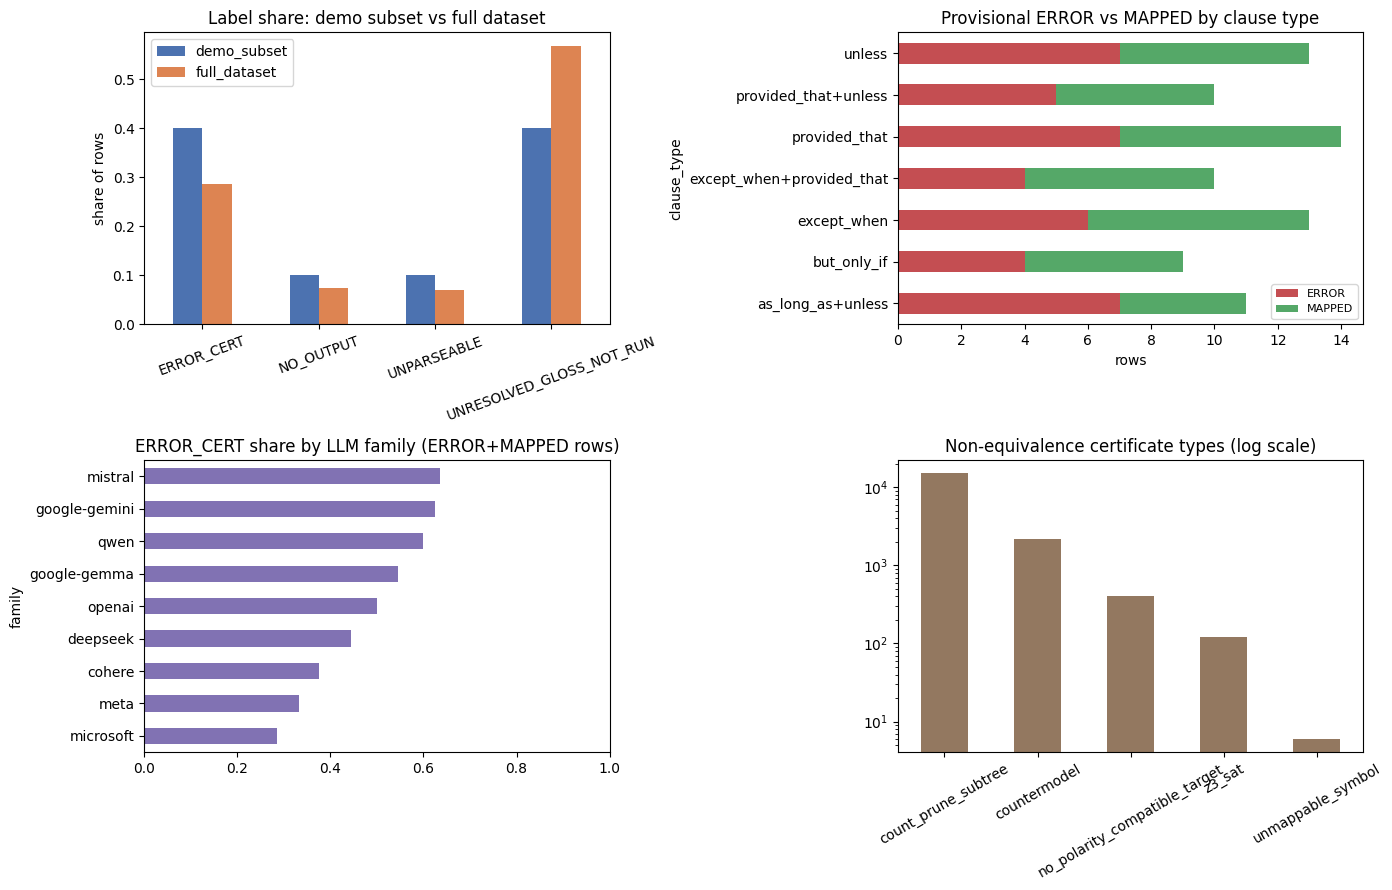

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) label counts: demo vs full (normalised)
(tab / tab.sum()).plot.bar(ax=axes[0, 0], color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Label share: demo subset vs full dataset")
axes[0, 0].set_ylabel("share of rows"); axes[0, 0].tick_params(axis="x", rotation=20)

# (b) provisional ERROR vs MAPPED by clause type
if len(bin_df):  # needs at least one ERROR/MAPPED row
    ct = pd.crosstab(bin_df["clause_type"], bin_df["label_binary_search_provisional"]).reindex(columns=["ERROR", "MAPPED"], fill_value=0)
    ct.plot.barh(stacked=True, ax=axes[0, 1], color={"ERROR": "#C44E52", "MAPPED": "#55A868"})
    axes[0, 1].legend(loc="lower right", fontsize=8)
axes[0, 1].set_title("Provisional ERROR vs MAPPED by clause type"); axes[0, 1].set_xlabel("rows")

# (c) ERROR share by LLM family (over ERROR+MAPPED rows)
if len(bin_df):
    fam = pd.crosstab(bin_df["family"], bin_df["label_binary_search_provisional"]).reindex(columns=["ERROR", "MAPPED"], fill_value=0)
    (fam["ERROR"] / fam.sum(axis=1)).astype(float).sort_values().plot.barh(ax=axes[1, 0], color="#8172B3")
axes[1, 0].set_title("ERROR_CERT share by LLM family (ERROR+MAPPED rows)"); axes[1, 0].set_xlim(0, 1)

# (d) non-equivalence certificate types
if cert_types:
    pd.Series(dict(cert_types.most_common())).plot.bar(ax=axes[1, 1], color="#937860", logy=True)
axes[1, 1].set_title("Non-equivalence certificate types (log scale)"); axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Reading the results.** `ERROR_CERT` rows come with a proof-style certificate that *no* name-free map rescues the candidate, so they are final relative to the bridge family. `MAPPED` rows are only **provisionally** correct: an audit of the SIG soundness replay showed that 9–10% of known-wrong formulas can be "rescued" by a non-identity symbol map. Catching those is the job of the pending gloss check (`src/resume_gloss.py` in the artifact). Because no `CORRECT` class exists yet, AUROC-type evaluations on this dataset are `NOT_TESTABLE`. Only the provisional ERROR-vs-MAPPED view is testable, with about 13% audited contamination on each side.